<a href="https://colab.research.google.com/github/natitedros/NLP-lab/blob/main/lab_1/rnn_lstm_gru_sentiment_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple RNN vs LSTM vs GRU for sentiment classification (IMDb)

This notebook trains three sequence models on the IMDb movie-review dataset with the **same data split and the same training budget**, then compares them.

**Before you run it:** go to `Runtime → Change runtime type → T4 GPU`, then `Runtime → Run all`. On a GPU the whole notebook should take somewhere around 10–20 minutes; the Simple RNN is the slow part (section 5 explains why). On CPU it will be much slower.

| Assignment item | Where it is |
|---|---|
| 1. Token sequences + Embedding layer | Sections 2–4 |
| 2. Simple RNN, LSTM, GRU | Section 4 |
| 3. Same split and training budget | Sections 3 and 5 |
| 4. Validation accuracy, training time, parameters, loss curves | Sections 4, 6, 7 |
| 5. Five new reviews, with explanations | Section 8 |
| Question: which model handles longer reviews better? | Sections 9–10 |

## 1. Setup

**What this cell does:** imports the libraries, fixes the random seed, and checks whether a GPU is attached.

**Why:** fixing the seed means the three models start from the same embedding initialisation and see the training batches in the same order, so differences in results come from the architecture and not from luck. The GPU check is there because training time is one of the things you have to report, and it depends heavily on the hardware.

In [ ]:
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split

layers = keras.layers

SEED = 42
keras.utils.set_random_seed(SEED)   # seeds Python, NumPy and TensorFlow together

gpus = tf.config.list_physical_devices("GPU")
print("TensorFlow version:", tf.__version__)
print("GPU attached:", "yes" if gpus else "NO - switch to a GPU runtime, otherwise training will be slow")

TensorFlow version: 2.20.0
GPU attached: yes


**What this cell does:** puts every setting that defines the experiment in one place.

**Why:** "same training budget" means all three models get identical values for everything below. Keeping them as constants makes that easy to check and easy to change.

- `VOCAB_SIZE = 10,000`: the number of distinct token IDs. Only the most frequent words get their own ID; rarer words are all mapped to one "unknown" ID.
- `MAXLEN = 500`: every review is cut or padded to exactly 500 tokens. This is deliberately long, because the final question is about long reviews. With a short window (say 100) no model would ever see a long sequence.
- `EMBED_DIM` and `UNITS`: the size of each word vector and of the recurrent layer's hidden state. Same for all three models.
- `EPOCHS`, `BATCH_SIZE`, `LEARNING_RATE`: the training budget.

In [ ]:
VOCAB_SIZE    = 10_000   # number of distinct word IDs the Embedding layer knows
MAXLEN        = 500      # tokens per review after padding / truncating
EMBED_DIM     = 64       # length of each word vector
UNITS         = 64       # hidden-state size of the recurrent layer
BATCH_SIZE    = 128
EPOCHS        = 5
LEARNING_RATE = 1e-3

MODEL_NAMES = ["SimpleRNN", "LSTM", "GRU"]
COLORS = {"SimpleRNN": "#2a78d6", "LSTM": "#eb6834", "GRU": "#1baf7a"}  # one fixed colour per model in every chart

## 2. Load the raw reviews

**What this cell does:** downloads IMDb as **raw text** from the Hugging Face hub: 25,000 training reviews and 25,000 test reviews, each with a label (`1` = positive, `0` = negative). It then prints one review exactly as it was written.

**Why:** starting from raw text means the conversion into token sequences is done by you, in this notebook, where you can see every step. Notice the capital letters, punctuation and `<br />` tags (HTML line breaks) in the printed review; the tokenizer in section 3 has to deal with all of them.

Colab may print a warning about a missing `HF_TOKEN`. That is harmless for a public dataset like this one.

In [ ]:
try:
    from datasets import load_dataset
except ImportError:                                   # Colab normally has this library already
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "datasets"], check=True)
    from datasets import load_dataset

raw = load_dataset("stanfordnlp/imdb")

train_texts_all = list(raw["train"]["text"])
y_train_all     = np.array(list(raw["train"]["label"]))
test_texts      = list(raw["test"]["text"])
y_test          = np.array(list(raw["test"]["label"]))

print(f"Training reviews: {len(train_texts_all):,}   Test reviews: {len(test_texts):,}")
print(f"Share of positive labels in training data: {y_train_all.mean():.2f}")
print("\nOne raw review (label = %d):" % y_train_all[0])
print(train_texts_all[0][:600])

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Training reviews: 25,000   Test reviews: 25,000
Share of positive labels in training data: 0.50

One raw review (label = 0):
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political is


## 3. Split the data, then convert the text into token sequences

**What this cell does:** splits the 25,000 training reviews into 20,000 for training and 5,000 for validation. The 25,000 test reviews are kept aside untouched.

**Why:**
- The split is made **once**, with a fixed seed, and reused for all three models. That is what "same train/validation split" means in practice. `stratify` keeps the positive/negative balance equal in both parts.
- The split comes **before** building the vocabulary on purpose. The vocabulary is part of what the model learns from the data, so it should be built from the training reviews only. Validation and test reviews then play the role of text the system has never seen.

In [ ]:
train_texts, val_texts, y_train, y_val = train_test_split(
    train_texts_all, y_train_all, test_size=0.2, random_state=SEED, stratify=y_train_all
)

print(f"Train: {len(train_texts):,}   Validation: {len(val_texts):,}   Test: {len(test_texts):,}")
print("Positive share - train: %.3f  val: %.3f  test: %.3f" % (y_train.mean(), y_val.mean(), y_test.mean()))

Train: 20,000   Validation: 5,000   Test: 25,000
Positive share - train: 0.500  val: 0.500  test: 0.500


**What this cell does:** this is the "convert reviews into token sequences" step, in three parts.
1. `tokenize` cleans a review and splits it into words: lower-case everything, remove the `<br />` tags, drop punctuation (an apostrophe inside a word is kept, so "don't" stays one token).
2. It counts every word in the **training** reviews and keeps the most frequent ones as the vocabulary. Each word gets an integer ID: the most common word is 2, the next is 3, and so on. ID `0` is reserved for padding and ID `1` for "unknown word", so `VOCAB_SIZE = 10,000` leaves room for 9,998 real words.
3. `encode_review` turns any text into a list of those IDs, and `decode_review` goes back the other way.

**Why:** a neural network cannot read strings, so each word has to become a number. These IDs are only labels, though: ID 57 is not "bigger" or "more positive" than ID 56. Giving the numbers meaning is the job of the Embedding layer in section 4, which looks up a trainable vector for each ID.

**What to look for in the output:** the most common words (expect "the", "and", "a", ...), how much of the training text the 9,998-word vocabulary covers, and a sample sentence encoded and decoded. Words outside the vocabulary come back as `<oov>`.

In [ ]:
from collections import Counter

PAD_ID, OOV_ID = 0, 1


def tokenize(text):
    # Review text -> list of lower-case words, without HTML line breaks or punctuation.
    text = text.lower().replace("<br />", " ")
    return re.findall(r"[a-z0-9]+(?:'[a-z]+)?", text)


# Build the vocabulary from the TRAINING reviews only.
word_counts = Counter(word for text in train_texts for word in tokenize(text))
vocab_words = [word for word, _ in word_counts.most_common(VOCAB_SIZE - 2)]

word_to_id = {word: i + 2 for i, word in enumerate(vocab_words)}      # 0 and 1 are reserved
id_to_word = {i: word for word, i in word_to_id.items()}
id_to_word.update({PAD_ID: "<pad>", OOV_ID: "<oov>"})


def encode_review(text):
    # Text -> list of token IDs; words outside the vocabulary become OOV_ID.
    return [word_to_id.get(word, OOV_ID) for word in tokenize(text)]


def decode_review(ids):
    # List of token IDs -> readable text.
    return " ".join(id_to_word[int(i)] for i in ids)


covered = sum(word_counts[w] for w in vocab_words) / sum(word_counts.values())
print(f"Distinct words in the training reviews: {len(word_counts):,}")
print(f"Vocabulary kept: {len(vocab_words):,} words, covering {covered:.1%} of all training tokens")
print("Ten most common words:", vocab_words[:10])

sample = "This movie was surprisingly good, I didn't expect that!"
print("\nText          :", sample)
print("Tokens        :", tokenize(sample))
print("Token IDs     :", encode_review(sample))
print("Decoded back  :", decode_review(encode_review(sample)))

Distinct words in the training reviews: 73,964
Vocabulary kept: 9,998 words, covering 94.4% of all training tokens
Ten most common words: ['the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i', 'this']

Text          : This movie was surprisingly good, I didn't expect that!
Tokens        : ['this', 'movie', 'was', 'surprisingly', 'good', 'i', "didn't", 'expect', 'that']
Token IDs     : [11, 17, 13, 1225, 49, 10, 159, 540, 12]
Decoded back  : this movie was surprisingly good i didn't expect that


**What this cell does:** encodes every review in the three sets, records how long each one is, and pads them into rectangular arrays of shape `(reviews, 500)`.

**Why:**
- A batch has to be a rectangular tensor, so every review needs the same length. `pad_sequences` pads short reviews with `0` **at the front** and, for reviews longer than 500, keeps the **last 500 tokens**. Padding at the front means the last thing each network reads is real text, not a run of zeros.
- The lengths are saved before padding because section 9 groups the test reviews by their original length. The histogram shows how many reviews are actually "long" and how many get truncated at 500 tokens.
- The test set is only used at the end (sections 6 and 9), so those numbers are an honest estimate on unseen data.

After this cell the data is ready: `x_train`, `x_val`, `x_test` hold token IDs and `y_train`, `y_val`, `y_test` hold the labels.

x_train: (20000, 500)  x_val: (5000, 500)  x_test: (25000, 500)
Review length in tokens: min 10, median 174, mean 233, 90th percentile 456, max 2473
Reviews longer than MAXLEN=500: 7.9%

Shortest training review as text: This movie is terrible but it has some good effects.
The end of its padded row (zeros first, then the token IDs):
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0  11  17   7 392  18   9  45  46  49 303]


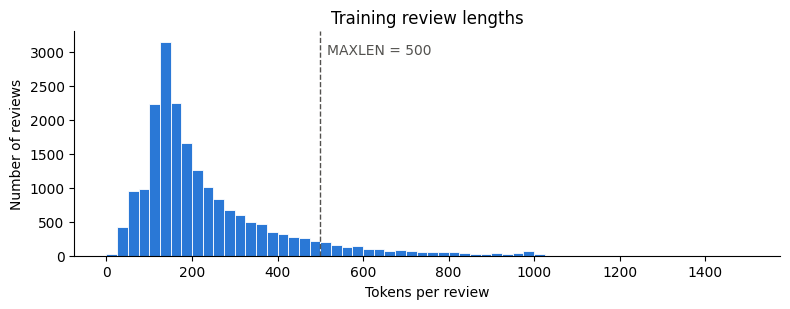

In [ ]:
train_ids = [encode_review(t) for t in train_texts]
val_ids   = [encode_review(t) for t in val_texts]
test_ids  = [encode_review(t) for t in test_texts]

train_len = np.array([len(ids) for ids in train_ids])        # lengths before padding / truncating
test_len  = np.array([len(ids) for ids in test_ids])

x_train = keras.utils.pad_sequences(train_ids, maxlen=MAXLEN)   # default: pad and truncate at the front
x_val   = keras.utils.pad_sequences(val_ids,   maxlen=MAXLEN)
x_test  = keras.utils.pad_sequences(test_ids,  maxlen=MAXLEN)

print("x_train:", x_train.shape, " x_val:", x_val.shape, " x_test:", x_test.shape)
print(f"Review length in tokens: min {train_len.min()}, median {np.median(train_len):.0f}, "
      f"mean {train_len.mean():.0f}, 90th percentile {np.percentile(train_len, 90):.0f}, max {train_len.max()}")
print(f"Reviews longer than MAXLEN={MAXLEN}: {(train_len > MAXLEN).mean():.1%}")

shortest = int(np.argmin(train_len))
print("\nShortest training review as text:", train_texts[shortest][:200])
print("The end of its padded row (zeros first, then the token IDs):")
print(x_train[shortest][-30:])

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(train_len, bins=60, range=(0, 1500), color=COLORS["SimpleRNN"], edgecolor="white", linewidth=0.6)
ax.axvline(MAXLEN, color="#52514e", linestyle="--", linewidth=1)
ax.text(MAXLEN + 15, ax.get_ylim()[1] * 0.9, f"MAXLEN = {MAXLEN}", color="#52514e")
ax.set_title("Training review lengths")
ax.set_xlabel("Tokens per review")
ax.set_ylabel("Number of reviews")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## 4. Define the three models

**What this cell does:** defines one function, `build_model`, that creates any of the three models. They are identical except for one line, the recurrent layer:

`token IDs → Embedding → [SimpleRNN | LSTM | GRU] → Dense(1, sigmoid)`

**Why each layer is there:**
- **Embedding** turns each token ID into a trainable 64-number vector. It is a lookup table with `VOCAB_SIZE × EMBED_DIM` weights, learned together with the rest of the model, so words used in similar ways end up with similar vectors.
- **The recurrent layer** reads the 500 vectors one at a time and keeps a hidden state. Only the state after the last token is passed on, so that state has to summarise the whole review.
  - *SimpleRNN*: new state = `tanh(W·input + U·old state + b)`. One set of weights, no mechanism to protect old information.
  - *LSTM*: adds a separate cell state plus three gates (forget, input, output) that decide what to keep, write and expose. Four sets of weights.
  - *GRU*: a lighter gated design with two gates (update, reset) and no separate cell state. Three sets of weights.
- **Dense(1, sigmoid)** maps the final state to one number between 0 and 1: the predicted probability that the review is positive.

**Why one shared function:** the optimiser (Adam), learning rate, loss and gradient clipping are set in one place, so they cannot accidentally differ between models. Gradient clipping (`clipnorm=1.0`) is applied to all three; it mainly keeps the Simple RNN from blowing up on 500-step sequences.

Padding is not masked. Masking would work, but it can push LSTM and GRU off their fast GPU implementation, and leaving it out treats the three models identically.

In [ ]:
RNN_LAYERS = {"SimpleRNN": layers.SimpleRNN, "LSTM": layers.LSTM, "GRU": layers.GRU}


def build_model(name):
    keras.utils.set_random_seed(SEED)        # same starting point for every model
    model = keras.Sequential(
        [
            keras.Input(shape=(MAXLEN,), dtype="int32"),
            layers.Embedding(VOCAB_SIZE, EMBED_DIM, name="embedding"),
            RNN_LAYERS[name](UNITS, name="recurrent"),
            layers.Dense(1, activation="sigmoid", name="classifier"),
        ],
        name=name,
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


build_model("LSTM").summary()

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ recurrent (LSTM)                │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

**What this cell does:** builds each model once and counts its parameters, layer by layer.

**Why:** "number of parameters" is one of the required numbers, and the breakdown shows something the total hides. The Embedding layer is the same size in all three models and holds most of the weights, so the totals look close. The architectures really differ in the **recurrent layer**, and that column is the fair comparison.

With input size `d = 64` and hidden size `h = 64`, one set of recurrent weights is `h × (d + h + 1) = 8,256`. So you should see:
- SimpleRNN: 1 set → 8,256
- LSTM: 4 sets → 33,024
- GRU: 3 sets → 24,960 (Keras's GRU keeps two bias vectors per gate, which adds 192 to 3 × 8,256)

In [ ]:
param_rows = []
for name in MODEL_NAMES:
    m = build_model(name)
    param_rows.append({
        "Model": name,
        "Embedding": m.get_layer("embedding").count_params(),
        "Recurrent layer": m.get_layer("recurrent").count_params(),
        "Classifier": m.get_layer("classifier").count_params(),
        "Total parameters": m.count_params(),
    })

param_table = pd.DataFrame(param_rows).set_index("Model")
display(param_table)

,Embedding,Recurrent layer,Classifier,Total parameters
Model,,,,
SimpleRNN,640000,8256,65,648321
LSTM,640000,33024,65,673089
GRU,640000,24960,65,665025


## 5. Train all three with the same budget

**What the first cell does:** defines a small callback, `EpochTracker`, that Keras calls at the start and end of every epoch. It records how long each epoch took and remembers the weights from the epoch with the lowest validation loss.

**Why:** every model trains for the full 5 epochs (identical budget), but a model can start overfitting before epoch 5. Keeping the best-validation weights means each model is later evaluated at its own best point, which is the standard way to use a validation set. Timing per epoch also lets you separate the first epoch (which includes one-off setup) from the rest.

In [ ]:
class EpochTracker(keras.callbacks.Callback):
    # Records time per epoch and keeps the weights from the best validation-loss epoch.

    def __init__(self):
        super().__init__()
        self.epoch_times = []
        self.best_val_loss = float("inf")
        self.best_epoch = None
        self.best_weights = None

    def on_epoch_begin(self, epoch, logs=None):
        self._start = time.perf_counter()

    def on_epoch_end(self, epoch, logs=None):
        self.epoch_times.append(time.perf_counter() - self._start)
        val_loss = (logs or {}).get("val_loss")
        if val_loss is not None and val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.best_epoch = epoch + 1                      # epochs are reported starting from 1
            self.best_weights = self.model.get_weights()

**What this cell does:** the actual experiment. For each of the three models it builds a fresh model, trains it for `EPOCHS` epochs on the same `x_train`, validates on the same `x_val`, measures the wall-clock time, restores the best weights, and stores everything in `models`, `histories` and `results`.

**What to watch in the output:** one line per epoch with training loss/accuracy and validation loss/accuracy (`val_`). If `val_loss` starts rising while `loss` keeps falling, the model has begun to overfit.

**A point you should mention in your report about training time:** on a GPU, Keras runs LSTM and GRU through cuDNN, a heavily optimised implementation. SimpleRNN has no cuDNN version and runs as an ordinary step-by-step loop. So the Simple RNN will probably be the *slowest* to train here even though it has the fewest parameters. That is an implementation effect, not a property of the architecture: per time step, the amount of arithmetic goes SimpleRNN < GRU < LSTM, in line with the parameter counts.

In [ ]:
models, histories, results = {}, {}, {}

for name in MODEL_NAMES:
    print(f"\n===== Training {name} =====")
    model = build_model(name)                # fresh model, so re-running this cell restarts from scratch
    tracker = EpochTracker()

    start = time.perf_counter()
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[tracker],
        verbose=2,
    )
    train_seconds = time.perf_counter() - start

    if tracker.best_weights is not None:     # go back to the best-validation epoch
        model.set_weights(tracker.best_weights)

    val_loss, val_acc = model.evaluate(x_val, y_val, batch_size=512, verbose=0)

    models[name] = model
    histories[name] = history.history
    results[name] = {
        "Validation accuracy": val_acc,
        "Validation loss": val_loss,
        "Best epoch": tracker.best_epoch,
        "Final-epoch val. accuracy": history.history["val_accuracy"][-1],
        "Training time (s)": train_seconds,
        "Seconds per epoch": float(np.mean(tracker.epoch_times)),
        "Recurrent-layer parameters": model.get_layer("recurrent").count_params(),
        "Total parameters": model.count_params(),
    }
    print(f"{name}: validation accuracy {val_acc:.4f} (best epoch {tracker.best_epoch}), "
          f"trained in {train_seconds:.0f} s")


===== Training SimpleRNN =====
Epoch 1/5
157/157 - 13s - 80ms/step - accuracy: 0.6943 - loss: 0.5678 - val_accuracy: 0.8198 - val_loss: 0.4233
Epoch 2/5
157/157 - 7s - 41ms/step - accuracy: 0.8496 - loss: 0.3548 - val_accuracy: 0.8178 - val_loss: 0.4405
Epoch 3/5
157/157 - 7s - 44ms/step - accuracy: 0.8960 - loss: 0.2639 - val_accuracy: 0.8644 - val_loss: 0.3682
Epoch 4/5
157/157 - 6s - 41ms/step - accuracy: 0.9083 - loss: 0.2383 - val_accuracy: 0.8024 - val_loss: 0.4247
Epoch 5/5
157/157 - 6s - 41ms/step - accuracy: 0.9293 - loss: 0.1906 - val_accuracy: 0.8366 - val_loss: 0.4398
SimpleRNN: validation accuracy 0.8644 (best epoch 3), trained in 43 s

===== Training LSTM =====
Epoch 1/5
157/157 - 8s - 54ms/step - accuracy: 0.7350 - loss: 0.5202 - val_accuracy: 0.8452 - val_loss: 0.3694
Epoch 2/5
157/157 - 4s - 23ms/step - accuracy: 0.8669 - loss: 0.3263 - val_accuracy: 0.8528 - val_loss: 0.3410
Epoch 3/5
157/157 - 4s - 23ms/step - accuracy: 0.9094 - loss: 0.2412 - val_accuracy: 0.8724 -

## 6. Results table: validation accuracy, training time, parameters

**What this cell does:** scores each model on the 25,000 test reviews, then collects every required number into one table.

**How to read it:**
- **Validation accuracy** is measured with the best-epoch weights; **Final-epoch val. accuracy** is what you would get without that step. A gap between the two means the model overfit in the later epochs.
- **Training time** is the total for all 5 epochs, including the validation pass after each one. It depends on the hardware, so state in your report that you used a Colab T4 GPU (or whatever you had).
- **Test accuracy** is an extra the assignment does not ask for, but it confirms the validation ranking on data that played no part in choosing the weights.

The test predictions are stored because section 9 reuses them.

In [ ]:
test_probs = {name: models[name].predict(x_test, batch_size=512, verbose=0).ravel() for name in MODEL_NAMES}
test_correct = {name: (test_probs[name] >= 0.5).astype(int) == y_test for name in MODEL_NAMES}

for name in MODEL_NAMES:
    results[name]["Test accuracy"] = float(test_correct[name].mean())

column_order = ["Validation accuracy", "Test accuracy", "Final-epoch val. accuracy", "Best epoch",
                "Training time (s)", "Seconds per epoch", "Recurrent-layer parameters", "Total parameters"]
results_table = pd.DataFrame.from_dict(results, orient="index")[column_order]
results_table.index.name = "Model"

display(results_table.round({"Validation accuracy": 4, "Test accuracy": 4, "Final-epoch val. accuracy": 4,
                             "Training time (s)": 1, "Seconds per epoch": 1}))

,Validation accuracy,Test accuracy,Final-epoch val. accuracy,Best epoch,Training time (s),Seconds per epoch,Recurrent-layer parameters,Total parameters
Model,,,,,,,,
SimpleRNN,0.8644,0.8438,0.8366,3,42.8,7.8,8256,648321
LSTM,0.8724,0.8733,0.8674,3,23.8,4.7,33024,673089
GRU,0.8690,0.8624,0.8402,4,20.5,4.1,24960,665025


## 7. Training and validation loss curves

**What this cell does:** plots, for each model, the training loss (solid line) and validation loss (dashed line) after every epoch. The three panels share one y-axis so you can compare heights directly, and the dot marks the epoch whose weights were kept.

**What to look for and write about:**
- **Both lines falling together:** the model is still learning things that generalise.
- **Training loss falling while validation loss turns upward:** overfitting. The model is memorising the training reviews. LSTM and GRU often do this after 2–3 epochs on IMDb.
- **Both lines flat near 0.69:** the model is stuck at chance level (0.69 ≈ ln 2, the loss of always predicting 50%). If the Simple RNN does this or learns only slowly, that is a symptom of vanishing gradients over 500 time steps and is useful evidence for the final question.
- **Jagged, unstable curves:** unstable training, also more typical of the Simple RNN.

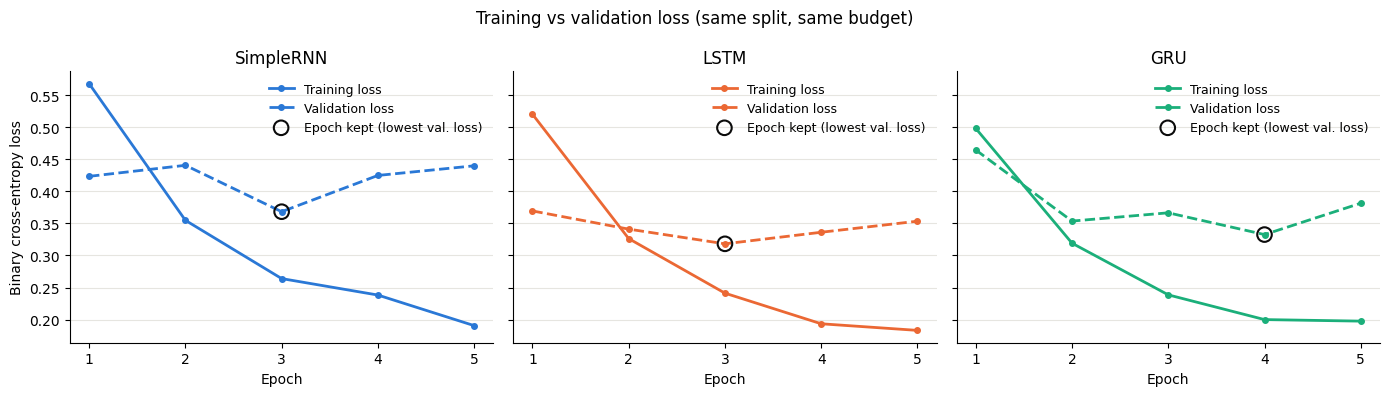

In [ ]:
epochs_axis = np.arange(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, name in zip(axes, MODEL_NAMES):
    h = histories[name]
    ax.plot(epochs_axis, h["loss"], color=COLORS[name], linewidth=2, marker="o", markersize=4, label="Training loss")
    ax.plot(epochs_axis, h["val_loss"], color=COLORS[name], linewidth=2, linestyle="--", marker="o",
            markersize=4, label="Validation loss")

    best = results[name]["Best epoch"]
    if best is not None and not pd.isna(best):
        best = int(best)
        ax.scatter([best], [h["val_loss"][best - 1]], s=110, facecolors="none", edgecolors="#0b0b0b",
                   linewidths=1.5, zorder=3, label="Epoch kept (lowest val. loss)")

    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_xticks(epochs_axis)
    ax.grid(axis="y", color="#e6e5e0", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, fontsize=9)

axes[0].set_ylabel("Binary cross-entropy loss")
fig.suptitle("Training vs validation loss (same split, same budget)")
fig.tight_layout()
plt.show()

## 8. Test on five new reviews

**What this cell does:** defines five reviews that are not in the dataset, encodes them with `encode_review` from section 3, pads them exactly like the training data, and prints each model's predicted probability of "positive" (0.5 or above counts as positive).

**Why these five:** each one probes something different, which gives you something concrete to explain.
1. **Clearly positive**: a sanity check.
2. **Clearly negative**: a sanity check.
3. **Negation**: "not bad at all" is positive, but it contains the word "bad". A model has to use word order, not just word counts.
4. **Sarcasm**: the surface words ("Great", "best") are positive, the meaning is negative. Expect models to struggle here.
5. **Long, with the opinion only at the start**: the verdict is in the first sentence, followed by a long, neutral plot summary. To get this right the model must carry the opinion through well over a hundred neutral words. This one ties directly to the final question.

Feel free to replace these with your own reviews; keep at least one long one.

In [ ]:
long_review = (
    "This is one of the best films I have seen in years and I loved every minute of it. "
    "The story follows a young woman who leaves her small town and travels to the city to look for her brother. "
    "She takes a room above a shop and finds work in a kitchen on the other side of the river. "
    "Every morning she walks across the bridge and every evening she asks people in the street whether they have seen him. "
    "A man who drives a delivery van tells her that her brother used to work at the harbour. "
    "She goes to the harbour and talks to the people who load the ships, and one of them gives her an address. "
    "The address leads to a house at the edge of the city, where an old woman lets her in and makes tea. "
    "The old woman explains that the brother stayed there for a winter and then left for the north with two other men. "
    "The second half of the film shows the journey north by train and then on foot through the hills. "
    "Along the way she meets a teacher, a farmer and a boy who is travelling alone. "
    "The film ends when she reaches the village where her brother now lives and knocks on his door."
)

new_reviews = [
    ("Clearly positive", 1,
     "An absolutely wonderful film. The acting was brilliant, the story was moving, and I enjoyed every scene."),
    ("Clearly negative", 0,
     "A complete waste of time. The plot was boring, the acting was terrible, and the ending made no sense."),
    ("Negation", 1,
     "I expected to hate this movie, but it was not bad at all. In fact I could not stop smiling."),
    ("Sarcasm", 0,
     "Great, another two hours of my life that I will never get back. The trailer was the best part."),
    ("Long, opinion only at the start", 1, long_review),
]


def prepare(texts):
    # Text -> padded array, ready for the models (same steps as the training data).
    return keras.utils.pad_sequences([encode_review(t) for t in texts], maxlen=MAXLEN)


def predict_positive(model, texts):
    # Probability that each text is a positive review.
    return model.predict(prepare(texts), batch_size=256, verbose=0).ravel()


new_texts = [text for _, _, text in new_reviews]
new_probs = {name: predict_positive(models[name], new_texts) for name in MODEL_NAMES}

rows = []
for i, (kind, expected, text) in enumerate(new_reviews):
    ids = encode_review(text)
    row = {
        "Review": f"{i + 1}. {kind}",
        "Tokens": len(ids),
        "Unknown words": sum(t == OOV_ID for t in ids),
        "Expected": "positive" if expected == 1 else "negative",
    }
    for name in MODEL_NAMES:
        p = new_probs[name][i]
        predicted = int(p >= 0.5)
        row[name] = f"{p:.2f} {'positive' if predicted else 'negative'} {'✓' if predicted == expected else '✗'}"
    rows.append(row)

display(pd.DataFrame(rows).set_index("Review"))

,Tokens,Unknown words,Expected,SimpleRNN,LSTM,GRU
Review,,,,,,
1. Clearly positive,17,0,positive,0.94 positive ✓,0.97 positive ✓,0.98 positive ✓
2. Clearly negative,19,0,negative,0.03 negative ✓,0.03 negative ✓,0.01 negative ✓
3. Negation,20,0,positive,0.10 negative ✗,0.35 negative ✗,0.55 positive ✓
4. Sarcasm,19,0,negative,0.61 positive ✗,0.97 positive ✗,0.97 positive ✗
"5. Long, opinion only at the start",218,2,positive,0.95 positive ✓,0.99 positive ✓,0.94 positive ✓


**What this cell does:** explains each prediction by measuring which words drove it. For every review it deletes one word at a time, re-runs the model, and records how much the predicted probability moved. The words whose removal changes the output most are the ones the model relied on.

**How to read the output:** a **positive** number means the word pushed the prediction **towards positive** (removing it lowered the probability); a **negative** number means it pushed towards negative. The numbers are changes in probability, so `+0.20` is a big effect and `+0.01` is negligible.

**How to turn this into your explanation.** For each review, write one or two sentences along these lines:
- *Reviews 1 and 2:* which sentiment words carried the decision ("wonderful", "terrible", ...)? All three models should agree with high confidence.
- *Review 3:* did "not" change the effect of "bad", or did "bad" and "hate" simply pull the score down? A model that gets this right is using context.
- *Review 4:* if a model says "positive", check whether "great" and "best" are its top words. That shows it reads surface vocabulary and has no way of detecting sarcasm.
- *Review 5:* do the influential words come from the first sentence ("best", "loved")? If a model's probability sits near 0.5 and no early word has much influence, it has forgotten the opening by the time it reaches the end. Compare the three models on this one.

A probability close to 0.5 means the model is unsure; close to 0 or 1 means it is confident.

In [ ]:
def word_influence(model, text, top_k=5):
    # Delete each word in turn and measure the change in the predicted probability.
    words = tokenize(text)
    base = predict_positive(model, [text])[0]
    variants = [" ".join(words[:i] + words[i + 1:]) for i in range(len(words))]
    effect = base - predict_positive(model, variants)        # > 0: the word pushed towards positive
    top = np.argsort(-np.abs(effect))[:top_k]
    return base, [(words[i], int(i) + 1, float(effect[i])) for i in top]


for i, (kind, expected, text) in enumerate(new_reviews):
    n_words = len(tokenize(text))
    print(f"\nReview {i + 1} - {kind} ({n_words} words, expected {'positive' if expected else 'negative'})")
    print("  " + (text if len(text) <= 110 else text[:110] + " ..."))
    for name in MODEL_NAMES:
        base, top_words = word_influence(models[name], text)
        described = ", ".join(f"{word} [word {pos}] {eff:+.2f}" for word, pos, eff in top_words)
        print(f"  {name:<9} p(positive) = {base:.2f} | most influential: {described}")


Review 1 - Clearly positive (17 words, expected positive)
  An absolutely wonderful film. The acting was brilliant, the story was moving, and I enjoyed every scene.
  SimpleRNN p(positive) = 0.94 | most influential: wonderful [word 3] +0.09, brilliant [word 8] +0.09, enjoyed [word 15] +0.06, moving [word 12] +0.04, and [word 13] +0.03
  LSTM      p(positive) = 0.97 | most influential: brilliant [word 8] +0.04, enjoyed [word 15] +0.03, moving [word 12] +0.03, wonderful [word 3] +0.02, scene [word 17] +0.01
  GRU       p(positive) = 0.98 | most influential: brilliant [word 8] +0.02, enjoyed [word 15] +0.01, moving [word 12] +0.01, wonderful [word 3] +0.01, every [word 16] -0.01

Review 2 - Clearly negative (19 words, expected negative)
  A complete waste of time. The plot was boring, the acting was terrible, and the ending made no sense.
  SimpleRNN p(positive) = 0.03 | most influential: no [word 18] -0.02, made [word 17] -0.01, ending [word 16] -0.01, sense [word 19] -0.01, terrible [w

## 9. Experiment for the question: accuracy by review length

**What this cell does:** groups the 25,000 test reviews into five buckets by their original length (before padding or truncation) and computes each model's accuracy inside each bucket.

**Why this is the right evidence:** overall accuracy mixes short and long reviews together. Splitting by length shows whether a model's accuracy holds up or falls as the sequence it has to remember gets longer. The test set is used because it is large (thousands of reviews per bucket) and unseen.

The last bucket, "> 500", contains reviews that were cut to their final 500 tokens, so every model reads a full 500-step sequence with no padding there.

In [ ]:
bucket_edges  = [0, 100, 200, 300, 500, np.inf]
bucket_labels = ["≤100", "101–200", "201–300", "301–500", ">500 (truncated)"]
test_bucket = pd.cut(test_len, bins=bucket_edges, labels=bucket_labels)

per_review = pd.DataFrame({"Review length (tokens)": test_bucket})
for name in MODEL_NAMES:
    per_review[name] = test_correct[name]

grouped = per_review.groupby("Review length (tokens)", observed=False)
length_table = grouped[MODEL_NAMES].mean()                  # accuracy per bucket
length_table.insert(0, "Reviews", grouped.size())

display(length_table.round(4))

,Reviews,SimpleRNN,LSTM,GRU
Review length (tokens),,,,
≤100,3163,0.8340,0.8783,0.8764
101–200,11759,0.8450,0.8793,0.8712
201–300,4668,0.8520,0.8719,0.8567
301–500,3529,0.8427,0.8626,0.8473
>500 (truncated),1881,0.8347,0.8506,0.8267


**What this cell does:** draws the table above as a line chart (one line per model) and prints a short summary: each model's accuracy on short reviews (100 tokens or fewer), on long reviews (more than 300 tokens), and the difference between the two.

**How to read it:**
- Compare the models **within the same bucket**. Every model is scored on exactly the same reviews there, so a gap between lines is caused by the architecture.
- Then look at how each gap **changes from left to right**. If the Simple RNN's line falls away from the other two as reviews get longer, that is direct evidence that it handles long reviews worse.
- Be careful with the slope of a single line taken alone. Long reviews are not just longer; they can be easier (more clues) or harder (more mixed opinions). That affects all models equally, which is why the comparison between models is the cleaner evidence.

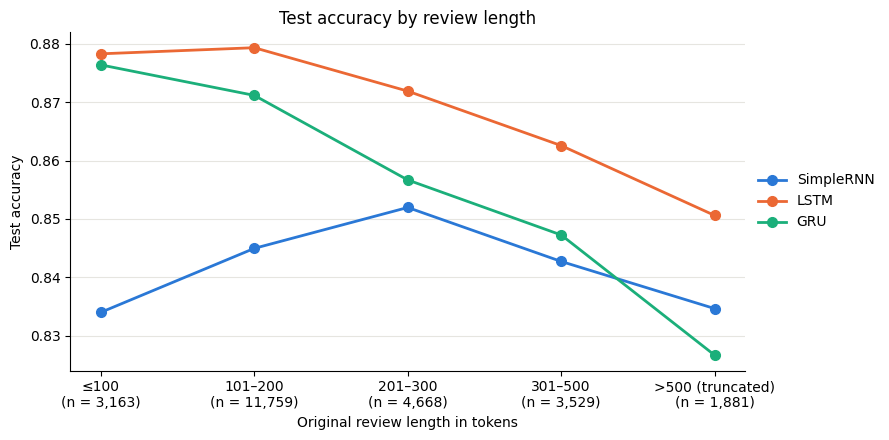

Short reviews: 3,163   Long reviews: 5,410


,"Accuracy, short (≤100 tokens)","Accuracy, long (>300 tokens)","Change, short → long"
Model,,,
SimpleRNN,0.8340,0.8399,0.0059
LSTM,0.8783,0.8584,-0.0199
GRU,0.8764,0.8401,-0.0363


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x_pos = np.arange(len(bucket_labels))

for name in MODEL_NAMES:
    acc = length_table[name].to_numpy(dtype=float)
    ax.plot(x_pos, acc, color=COLORS[name], linewidth=2, marker="o", markersize=7, label=name)

ax.set_xticks(x_pos)
ax.set_xticklabels([f"{label}\n(n = {int(n):,})" for label, n in zip(bucket_labels, length_table["Reviews"])])
ax.set_xlabel("Original review length in tokens")
ax.set_ylabel("Test accuracy")
ax.set_title("Test accuracy by review length")
ax.grid(axis="y", color="#e6e5e0", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.0, 0.5))   # beside the plot, clear of the lines
fig.tight_layout()
plt.show()

short_mask = test_len <= 100
long_mask  = test_len > 300

summary_rows = []
for name in MODEL_NAMES:
    short_acc = float(test_correct[name][short_mask].mean())
    long_acc  = float(test_correct[name][long_mask].mean())
    summary_rows.append({
        "Model": name,
        "Accuracy, short (≤100 tokens)": short_acc,
        "Accuracy, long (>300 tokens)": long_acc,
        "Change, short → long": long_acc - short_acc,
    })

length_summary = pd.DataFrame(summary_rows).set_index("Model")
print(f"Short reviews: {int(short_mask.sum()):,}   Long reviews: {int(long_mask.sum()):,}")
display(length_summary.round(4))

## 10. Answering the question

**What this cell does:** pulls the numbers that matter for the question out of your results and prints them as plain sentences, so you can quote them.

It reports which model was most accurate on long reviews, the accuracy difference between that model and each of the others (on long and on short reviews, so you can see whether the gap grows with length), and how each model did on the long opinion-first review from section 8.

In [ ]:
long_acc = length_summary["Accuracy, long (>300 tokens)"]
short_acc = length_summary["Accuracy, short (≤100 tokens)"]
best_long = long_acc.idxmax()

print(f"Evidence 1 - accuracy on long test reviews (> 300 tokens, n = {int(long_mask.sum()):,}):")
for name in MODEL_NAMES:
    print(f"  {name:<9} {long_acc[name]:.4f}   (short reviews: {short_acc[name]:.4f}, "
          f"change {long_acc[name] - short_acc[name]:+.4f})")
print(f"  Most accurate on long reviews: {best_long}")
for name in MODEL_NAMES:
    if name != best_long:
        gap_long = long_acc[best_long] - long_acc[name]
        gap_short = short_acc[best_long] - short_acc[name]
        print(f"  {best_long} minus {name}: {gap_long:+.4f} on long reviews, {gap_short:+.4f} on short reviews")

print("\nEvidence 2 - validation accuracy and loss curves:")
for name in MODEL_NAMES:
    print(f"  {name:<9} validation accuracy {results[name]['Validation accuracy']:.4f}, "
          f"lowest validation loss {min(histories[name]['val_loss']):.4f} at epoch {results[name]['Best epoch']}")

print("\nEvidence 3 - the long review with the opinion only in its first sentence (expected: positive):")
for name in MODEL_NAMES:
    p = new_probs[name][-1]
    print(f"  {name:<9} p(positive) = {p:.2f} -> {'positive (correct)' if p >= 0.5 else 'negative (wrong)'}")

Evidence 1 - accuracy on long test reviews (> 300 tokens, n = 5,410):
  SimpleRNN 0.8399   (short reviews: 0.8340, change +0.0059)
  LSTM      0.8584   (short reviews: 0.8783, change -0.0199)
  GRU       0.8401   (short reviews: 0.8764, change -0.0363)
  Most accurate on long reviews: LSTM
  LSTM minus SimpleRNN: +0.0185 on long reviews, +0.0443 on short reviews
  LSTM minus GRU: +0.0183 on long reviews, +0.0019 on short reviews

Evidence 2 - validation accuracy and loss curves:
  SimpleRNN validation accuracy 0.8644, lowest validation loss 0.3682 at epoch 3
  LSTM      validation accuracy 0.8724, lowest validation loss 0.3181 at epoch 3
  GRU       validation accuracy 0.8690, lowest validation loss 0.3326 at epoch 4

Evidence 3 - the long review with the opinion only in its first sentence (expected: positive):
  SimpleRNN p(positive) = 0.95 -> positive (correct)
  LSTM      p(positive) = 0.99 -> positive (correct)
  GRU       p(positive) = 0.94 -> positive (correct)


### Writing your answer

Use the numbers printed above; do not copy an expected result. A structure that works:

> **Claim.** *[Model]* handled longer reviews best.
>
> **Evidence 1 (accuracy by length).** On test reviews longer than 300 tokens it reached *[x]* accuracy, against *[y]* and *[z]* for the other two. Its lead over the Simple RNN was *[a]* points on long reviews but only *[b]* points on reviews of 100 tokens or fewer, so the gap widens as reviews get longer.
>
> **Evidence 2 (training behaviour).** *[Describe the loss curves: did the Simple RNN's validation loss stay higher, flatten near 0.69, or jump around while the gated models fell smoothly?]*
>
> **Evidence 3 (long new review).** On the review whose opinion appears only in the first sentence, *[which models stayed confident and correct, which drifted towards 0.5 or got it wrong]*, and the word-influence output showed *[whether the early words "best" / "loved" still mattered]*.
>
> **Why.** In a Simple RNN the hidden state is completely rewritten at every step, and the gradient has to pass through the same weight matrix and a `tanh` 500 times, so it shrinks towards zero (the vanishing-gradient problem); the model cannot learn to connect an early word to the final prediction. LSTM and GRU have gates that can leave part of the state almost unchanged from one step to the next, which keeps both the information and the gradient alive across long spans.
>
> **Cost.** That ability is paid for in parameters: the LSTM's recurrent layer has 4× and the GRU's 3× the weights of the Simple RNN's.

**What you will most likely see:** LSTM and GRU close to each other and clearly ahead of the Simple RNN overall, with the Simple RNN's disadvantage largest on the long buckets. LSTM versus GRU is usually too close to call on IMDb; if their difference is under about one point, say they performed comparably instead of declaring a winner, since a different random seed could swap them. If your run shows something else, report what you actually got and discuss why.

**Honest limitations worth one sentence in your report:**
- Each model was trained once with one seed; repeating with 3 seeds and averaging would make small differences trustworthy.
- Reviews over 500 tokens were truncated, so "long" here means up to 500 tokens.
- Training time on a GPU reflects cuDNN support as much as model complexity (section 5).

**Optional extension** if you want stronger evidence: set `MAXLEN = 100` in section 1, re-run everything, and compare with the `MAXLEN = 500` results. A model that can use long context should gain accuracy from the longer window; a model that cannot will gain little or even get worse.